In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df=pd.read_csv(r"C:\Users\asus\Desktop\Datasets\samsung_global_sales_dataset.csv")
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,ARS,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,ARS,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,ARS,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,ARS,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,ARS,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept


In [29]:
df.shape

(15500, 28)

In [30]:
# find all the columns name: 
df.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'storage', 'color', 'is_5g',
       'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd',
       'revenue_usd', 'currency', 'fx_rate_to_usd', 'revenue_local_currency',
       'sales_channel', 'payment_method', 'customer_segment',
       'customer_age_group', 'previous_device_os', 'customer_rating',
       'return_status'],
      dtype='object')

In [31]:
# columns kis data type ke hai.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  object 
 1   sale_date               15500 non-null  object 
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  object 
 4   month                   15500 non-null  object 
 5   country                 15500 non-null  object 
 6   region                  15500 non-null  object 
 7   city                    15500 non-null  object 
 8   product_name            15500 non-null  object 
 9   category                15500 non-null  object 
 10  storage                 7651 non-null   object 
 11  color                   15500 non-null  object 
 12  is_5g                   15500 non-null  object 
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null

In [32]:
# kis column me null values hai or kitni.
df.isnull().sum()

sale_id                      0
sale_date                    0
year                         0
quarter                      0
month                        0
country                      0
region                       0
city                         0
product_name                 0
category                     0
storage                   7849
color                        0
is_5g                        0
unit_price_usd               0
discount_pct                 0
units_sold                   0
discounted_price_usd         0
revenue_usd                  0
currency                     0
fx_rate_to_usd               0
revenue_local_currency       0
sales_channel                0
payment_method               0
customer_segment             0
customer_age_group           0
previous_device_os        9373
customer_rating           4251
return_status                0
dtype: int64

In [33]:
# category ki values count.
df['category'].value_counts()

category
Galaxy S        2316
Accessories     2101
Galaxy A        1892
Galaxy Tab      1524
Galaxy Watch    1486
Smart TV        1295
Galaxy Z        1058
Appliances      1052
Monitor         1046
Galaxy Buds      869
Galaxy M         861
Name: count, dtype: int64

In [34]:
# storage kis kis category me ata hai.
df.groupby('category')['storage'].apply(lambda x: x.notnull().sum())

category
Accessories        0
Appliances         0
Galaxy A        1892
Galaxy Buds        0
Galaxy M         861
Galaxy S        2316
Galaxy Tab      1524
Galaxy Watch       0
Galaxy Z        1058
Monitor            0
Smart TV           0
Name: storage, dtype: int64

In [35]:
# sale_date object hai usko time and date me convert kro.
df['sale_date'] = pd.to_datetime(df['sale_date'])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   sale_id                 15500 non-null  object        
 1   sale_date               15500 non-null  datetime64[ns]
 2   year                    15500 non-null  int64         
 3   quarter                 15500 non-null  object        
 4   month                   15500 non-null  object        
 5   country                 15500 non-null  object        
 6   region                  15500 non-null  object        
 7   city                    15500 non-null  object        
 8   product_name            15500 non-null  object        
 9   category                15500 non-null  object        
 10  storage                 7651 non-null   object        
 11  color                   15500 non-null  object        
 12  is_5g                   15500 non-null  object

In [37]:
# month column add krne ke liye
df['month_number']= df['sale_date'].dt.month

In [38]:
# day_name ka column add krne ke liye.
df['day_name']= df['sale_date'].dt.day_name()

In [39]:
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status,month_number,day_name
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept,1,Friday
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept,3,Tuesday
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept,5,Saturday
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept,7,Monday
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept,9,Thursday


In [40]:
# profit per unit (discount impact samajhne ke liye)
df['price_drop']= df['unit_price_usd']-df['discounted_price_usd']

In [41]:
df['return_flag']= df['return_status'].apply(lambda x: 1 if x == 'Returned' else 0)

In [42]:
# months ki max or min values find .
print(df['month_number'].min())
df['month_number'].max()

1


12

In [43]:
# kon kon se months number exist krte hai thumera data me.
df['month_number'].unique()

array([ 1,  3,  5,  7,  9, 11,  2,  6,  8, 12,  4, 10], dtype=int32)

In [44]:
# months name jo exist krte hai.
df['month'].unique()

array(['January', 'March', 'May', 'July', 'September', 'November',
       'February', 'June', 'August', 'December', 'April', 'October'],
      dtype=object)

In [45]:
# days name jo exist krte hai.
df['day_name'].unique()

array(['Friday', 'Tuesday', 'Saturday', 'Monday', 'Thursday', 'Wednesday',
       'Sunday'], dtype=object)

In [46]:
df['return_flag'].value_counts()

return_flag
0    14073
1     1427
Name: count, dtype: int64

In [47]:
# Total revenue find krne ke liye.
total_revenue= df['revenue_usd'].sum()
total_revenue

np.float64(22911258.88)

In [48]:
# Region wise Revenue.
df.groupby('region')['revenue_usd'].sum().sort_values(ascending=False)

region
Europe           7903104.02
Asia             6732880.38
Africa           2223891.75
South America    2119745.70
North America    1363648.44
Middle East       887007.49
Europe/Asia       866429.72
Oceania           814551.38
Name: revenue_usd, dtype: float64

In [49]:
# unit sold by region.
df.groupby('region')['units_sold'].sum().sort_values(ascending=False)

region
Europe           12517
Asia             10739
Africa            3522
South America     3466
North America     2169
Middle East       1408
Europe/Asia       1386
Oceania           1373
Name: units_sold, dtype: int64

In [50]:
# har region ka average revenue per unit calculate.
region_summary = df.groupby('region').agg({
    'revenue_usd': 'sum',
    'units_sold': 'sum'
})

region_summary['avg_revenue_per_unit'] = (
    region_summary['revenue_usd'] / region_summary['units_sold']
)

region_summary.sort_values('avg_revenue_per_unit', ascending=False)

,revenue_usd,units_sold,avg_revenue_per_unit
region,,,
Africa,2223891.75,3522,631.428663
Europe,7903104.02,12517,631.389632
Middle East,887007.49,1408,629.976911
North America,1363648.44,2169,628.699142
Asia,6732880.38,10739,626.955990
Europe/Asia,866429.72,1386,625.129668
South America,2119745.70,3466,611.582718
Oceania,814551.38,1373,593.263933


In [51]:
# Region-wise average discount calculate karo.
df.groupby('region')['discount_pct'].mean().sort_values(ascending=False)

region
Africa           5.964947
South America    5.770748
Europe           5.763469
Europe/Asia      5.746293
Middle East      5.701188
North America    5.628697
Asia             5.570632
Oceania          5.540765
Name: discount_pct, dtype: float64

In [52]:
# Kaunse product categories revenue drive kar rahe hain
df.groupby('category')['revenue_usd'].sum().sort_values(ascending=False)

category
Smart TV        5559342.55
Galaxy S        4728112.37
Galaxy Z        2765867.41
Galaxy Tab      2451712.69
Appliances      2253734.40
Monitor         2125195.20
Galaxy A        1154772.22
Galaxy Watch     913148.29
Galaxy M         425853.53
Galaxy Buds      298759.24
Accessories      234760.98
Name: revenue_usd, dtype: float64

In [53]:
# Category-wise Revenue
df.groupby('category')['revenue_usd'].sum().sort_values(ascending=False)

category
Smart TV        5559342.55
Galaxy S        4728112.37
Galaxy Z        2765867.41
Galaxy Tab      2451712.69
Appliances      2253734.40
Monitor         2125195.20
Galaxy A        1154772.22
Galaxy Watch     913148.29
Galaxy M         425853.53
Galaxy Buds      298759.24
Accessories      234760.98
Name: revenue_usd, dtype: float64

In [54]:
# Units Sold by Category
df.groupby('category')['units_sold'].sum().sort_values(ascending=False)

category
Galaxy S        5567
Accessories     4875
Galaxy A        4498
Galaxy Tab      3706
Galaxy Watch    3453
Smart TV        2941
Appliances      2508
Monitor         2486
Galaxy Z        2436
Galaxy M        2112
Galaxy Buds     1998
Name: units_sold, dtype: int64

In [55]:
# Combiuned table
category_summary = df.groupby('category').agg({
    'revenue_usd': 'sum',
    'units_sold': 'sum'
})

category_summary['avg_revenue_per_unit'] = (
    category_summary['revenue_usd'] / category_summary['units_sold']
)

category_summary.sort_values('revenue_usd', ascending=False)

,revenue_usd,units_sold,avg_revenue_per_unit
category,,,
Smart TV,5559342.55,2941,1890.289884
Galaxy S,4728112.37,5567,849.310647
Galaxy Z,2765867.41,2436,1135.413551
Galaxy Tab,2451712.69,3706,661.552264
Appliances,2253734.40,2508,898.618182
Monitor,2125195.20,2486,854.865326
Galaxy A,1154772.22,4498,256.730151
Galaxy Watch,913148.29,3453,264.450707
Galaxy M,425853.53,2112,201.635194


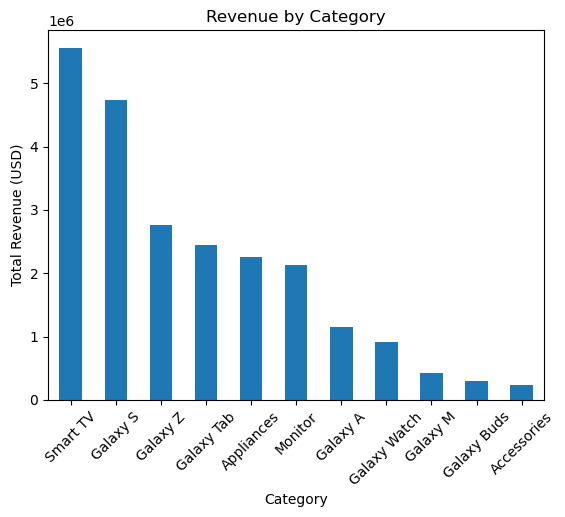

In [56]:
# Revenue by Category
import matplotlib.pyplot as plt

category_revenue = df.groupby('category')['revenue_usd'].sum().sort_values(ascending=False)

plt.figure()
category_revenue.plot(kind='bar')
plt.xlabel("Category")
plt.ylabel("Total Revenue (USD)")
plt.title("Revenue by Category")
plt.xticks(rotation=45)
plt.show()